In [135]:
import wfdb
import pandas as pd
import utils
import importlib
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import math

In [136]:
# Load the Excel file (adjust path and sheet name as needed)
df_time = pd.read_excel('ReportHome75h.xlsx')

def get_start_timestamp(df, filename):
    # Filter the row with the filename
    row = df[df.iloc[:, 0] == filename]
    if row.empty:
        raise ValueError(f"Filename {filename} not found in data")
    
    # Extract date and time columns (adjust column names if different)
    timestamp_str = row.iloc[:, [3,4]]
    date_str = timestamp_str['0 day'].iloc[0]       # first row date
    time_str = timestamp_str['Unnamed: 4'].iloc[0]  # first row time

    # Convert to datetime
    timestamp = pd.to_datetime(f"{date_str} {time_str}")
    return timestamp

In [137]:
reload = False

if reload:
    # file names from CO-001 to CO-044 and FL-001 to FL-036
    file_names = [f"CO-{i:03d}" for i in range(1, 45)] + [f"FL-{i:03d}" for i in range(1, 37)]

    for file_name in file_names:
        try:
            path = f"physionet.org/files/ltmm/1.0.0/{file_name.replace('-', '')}"
            output_path = f"minute_level/{file_name.replace('-', '')}.csv"

            # Read the record (without specifying extension)
            record = wfdb.rdrecord(path)

            # Convert to pandas DataFrame
            df = pd.DataFrame(record.p_signal, columns=record.sig_name)

            # Keep only the three acceleration columns
            acc_df = df[['v-acceleration', 'ml-acceleration', 'ap-acceleration']]

            try:
                start_ts = get_start_timestamp(df_time, file_name)

            except Exception as e:
                print(f"Could not find start timestamp for {file_name}: {e}")

                f1 = ["CO-025", "CO-036", "CO-038", "CO-044", "FL-028", "FL-032", "FL-034"]
                f2 = ["FL-010", "FL-015", "FL-020", "FL-024", "FL-026", "FL-029", "FL-030"]

                if file_name in f1:
                    start_ts = pd.Timestamp('1970-01-01 12:00:00')
                elif file_name in f2:
                    start_ts = pd.Timestamp('1970-01-01 18:00:00')
                else:
                    start_ts = pd.Timestamp('1970-01-01 00:00:00')

            acc_df = acc_df[['v-acceleration', 'ml-acceleration', 'ap-acceleration']].copy()

            sampling_rate = 100
            acc_df['time_s'] = acc_df.index / sampling_rate

            start_time = pd.Timestamp(start_ts, tz='UTC')
            acc_df['timestamp'] = start_time + pd.to_timedelta(acc_df.index / sampling_rate, unit='s')

            acc_df = acc_df.drop(columns=['time_s'])
            acc_df = acc_df.set_index('timestamp')

            acc_df = acc_df.rename(columns={
                'ml-acceleration': 'x',
                'ap-acceleration': 'y',
                'v-acceleration': 'z'
            })

            acc_df = acc_df[['x', 'y', 'z']]

            # calibration
            def calibrate_acc(df):
                time = pd.to_datetime(df.index)
                # Fix: use time[0] instead of time.iloc[0] because time is a DatetimeIndex
                time = (time - time[0]).total_seconds().to_numpy()
                accel = df[['x', 'y', 'z']].to_numpy()
                fs = 1 / np.median(np.diff(time))

                from skdh.preprocessing import CalibrateAccelerometer
                calibrator = CalibrateAccelerometer(min_hours=24, sd_criteria=0.05)
                results = calibrator.predict(time=time, accel=accel, fs=fs, apply=True)
                df[['x', 'y', 'z']] = accel
                return df

            acc_df = calibrate_acc(acc_df)

            def low_pass_filter(x, cutoff):
                from scipy.signal import butter, filtfilt
                nyquist = 0.5 * 100
                normal_cutoff = cutoff / nyquist
                b, a = butter(4, normal_cutoff, btype='low', analog=False)
                return filtfilt(b, a, x)

            acc_df = acc_df.resample('1min').mean()

            cutoff = 2
            acc_df['x'] = low_pass_filter(acc_df['x'], cutoff)
            acc_df['y'] = low_pass_filter(acc_df['y'], cutoff)
            acc_df['z'] = low_pass_filter(acc_df['z'], cutoff)

            # Convert index (DatetimeIndex) to ISO 8601 strings with milliseconds and Z
            acc_df['timestamp'] = acc_df.index.to_series().dt.strftime('%Y-%m-%d %H:%M:%S')#.str[:-3] + 'Z'

            acc_df = acc_df[['timestamp','x', 'y', 'z']]

            acc_df.to_csv(output_path, index=False)

        except Exception as e:
            print(f"{file_name} error: {e}")

### Computation of Wear Periods

**Purpose**: Identify valid wear periods from raw accelerometer data to ensure data quality and remove periods when the device was not worn.

**Methodology**: The wear period detection algorithm uses statistical criteria to distinguish between periods of actual device wear and non-wear:

- **Standard Deviation Criterion (sd_crit=0.015)**: During non-wear periods, accelerometer readings tend to have very low variability since the device is stationary. A threshold of 0.015 helps identify these low-variance periods.

- **Range Criterion (range_crit=0.001)**: Non-wear periods also exhibit minimal range in accelerometer values. The range criterion complements the standard deviation approach.

- **Window Length (window_length=20)**: The algorithm examines 20-minute windows to make wear/non-wear decisions, providing a balance between sensitivity and noise reduction.

- **Minimum Duration (min_duration_minutes_wear=20)**: Only periods lasting at least 20 minutes are considered valid wear periods, filtering out brief artifacts.

**Output**: The algorithm generates a `wear_periods_recomputed.csv` file containing start and end times for each valid wear period for every participant.

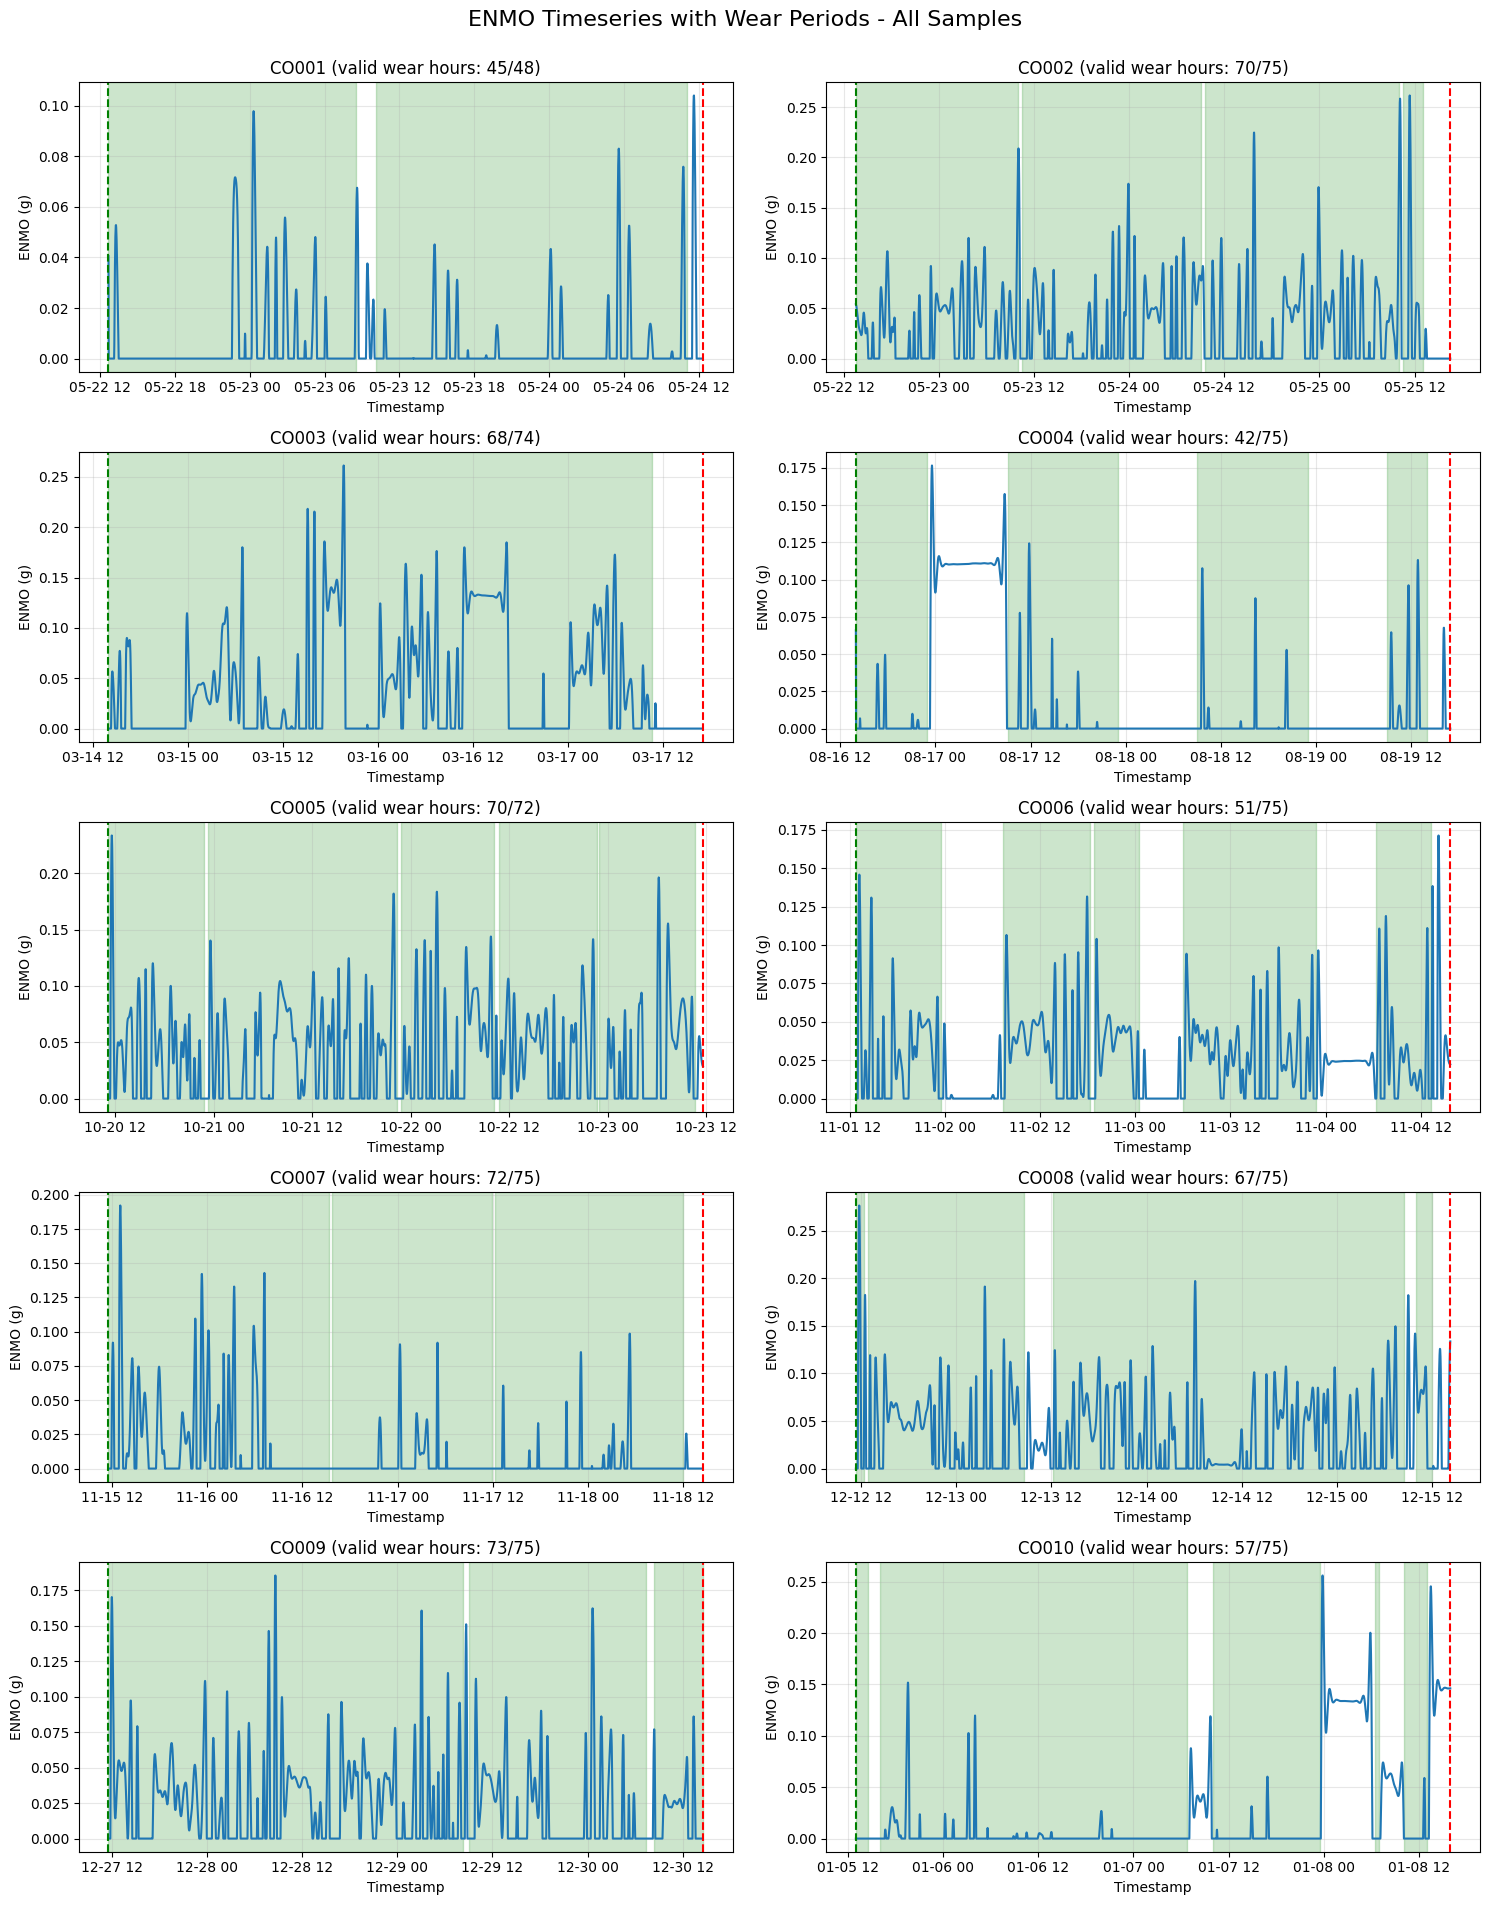

In [138]:
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries

reload = True

if reload:
    recompute_wear_periods(    
        sd_crit=0.015,
        range_crit=0.001,
        window_length=20,
        min_duration_minutes_wear=20
    )

wear_file_name = "wear_periods.csv"
orig_data_dir = "minute_level"
plot_pig_wear_timeseries(wear_file_name, orig_data_dir, axis='enmo', limit=10)

### Modification of Values During Non-Wear Periods

**Purpose**: Preserve circadian rhythm patterns while handling non-wear periods appropriately to maintain the integrity of 24-hour activity profiles.

**Methodology**: The smart filling strategy uses a **hierarchical fallback approach** with four strategies to fill non-wear periods while preserving circadian patterns:

#### Strategy 1: Exact Temporal Matching
- Finds same time on different days of the week
- Captures day-of-week patterns (weekday vs weekend)
- Most physiologically accurate

#### Strategy 2: Temporal Proximity
- Uses same time ±30 minutes on other days
- Accounts for routine variations
- Preserves circadian phase

#### Strategy 3: Local Context
- Uses nearby wear periods within 2 hours
- Captures gradual activity changes
- More flexible than exact matching

#### Strategy 4: Day/Night Awareness
- Daytime: mean of all daytime wear periods
- Nighttime: mean of all nighttime wear periods
- Preserves fundamental sleep-wake contrast

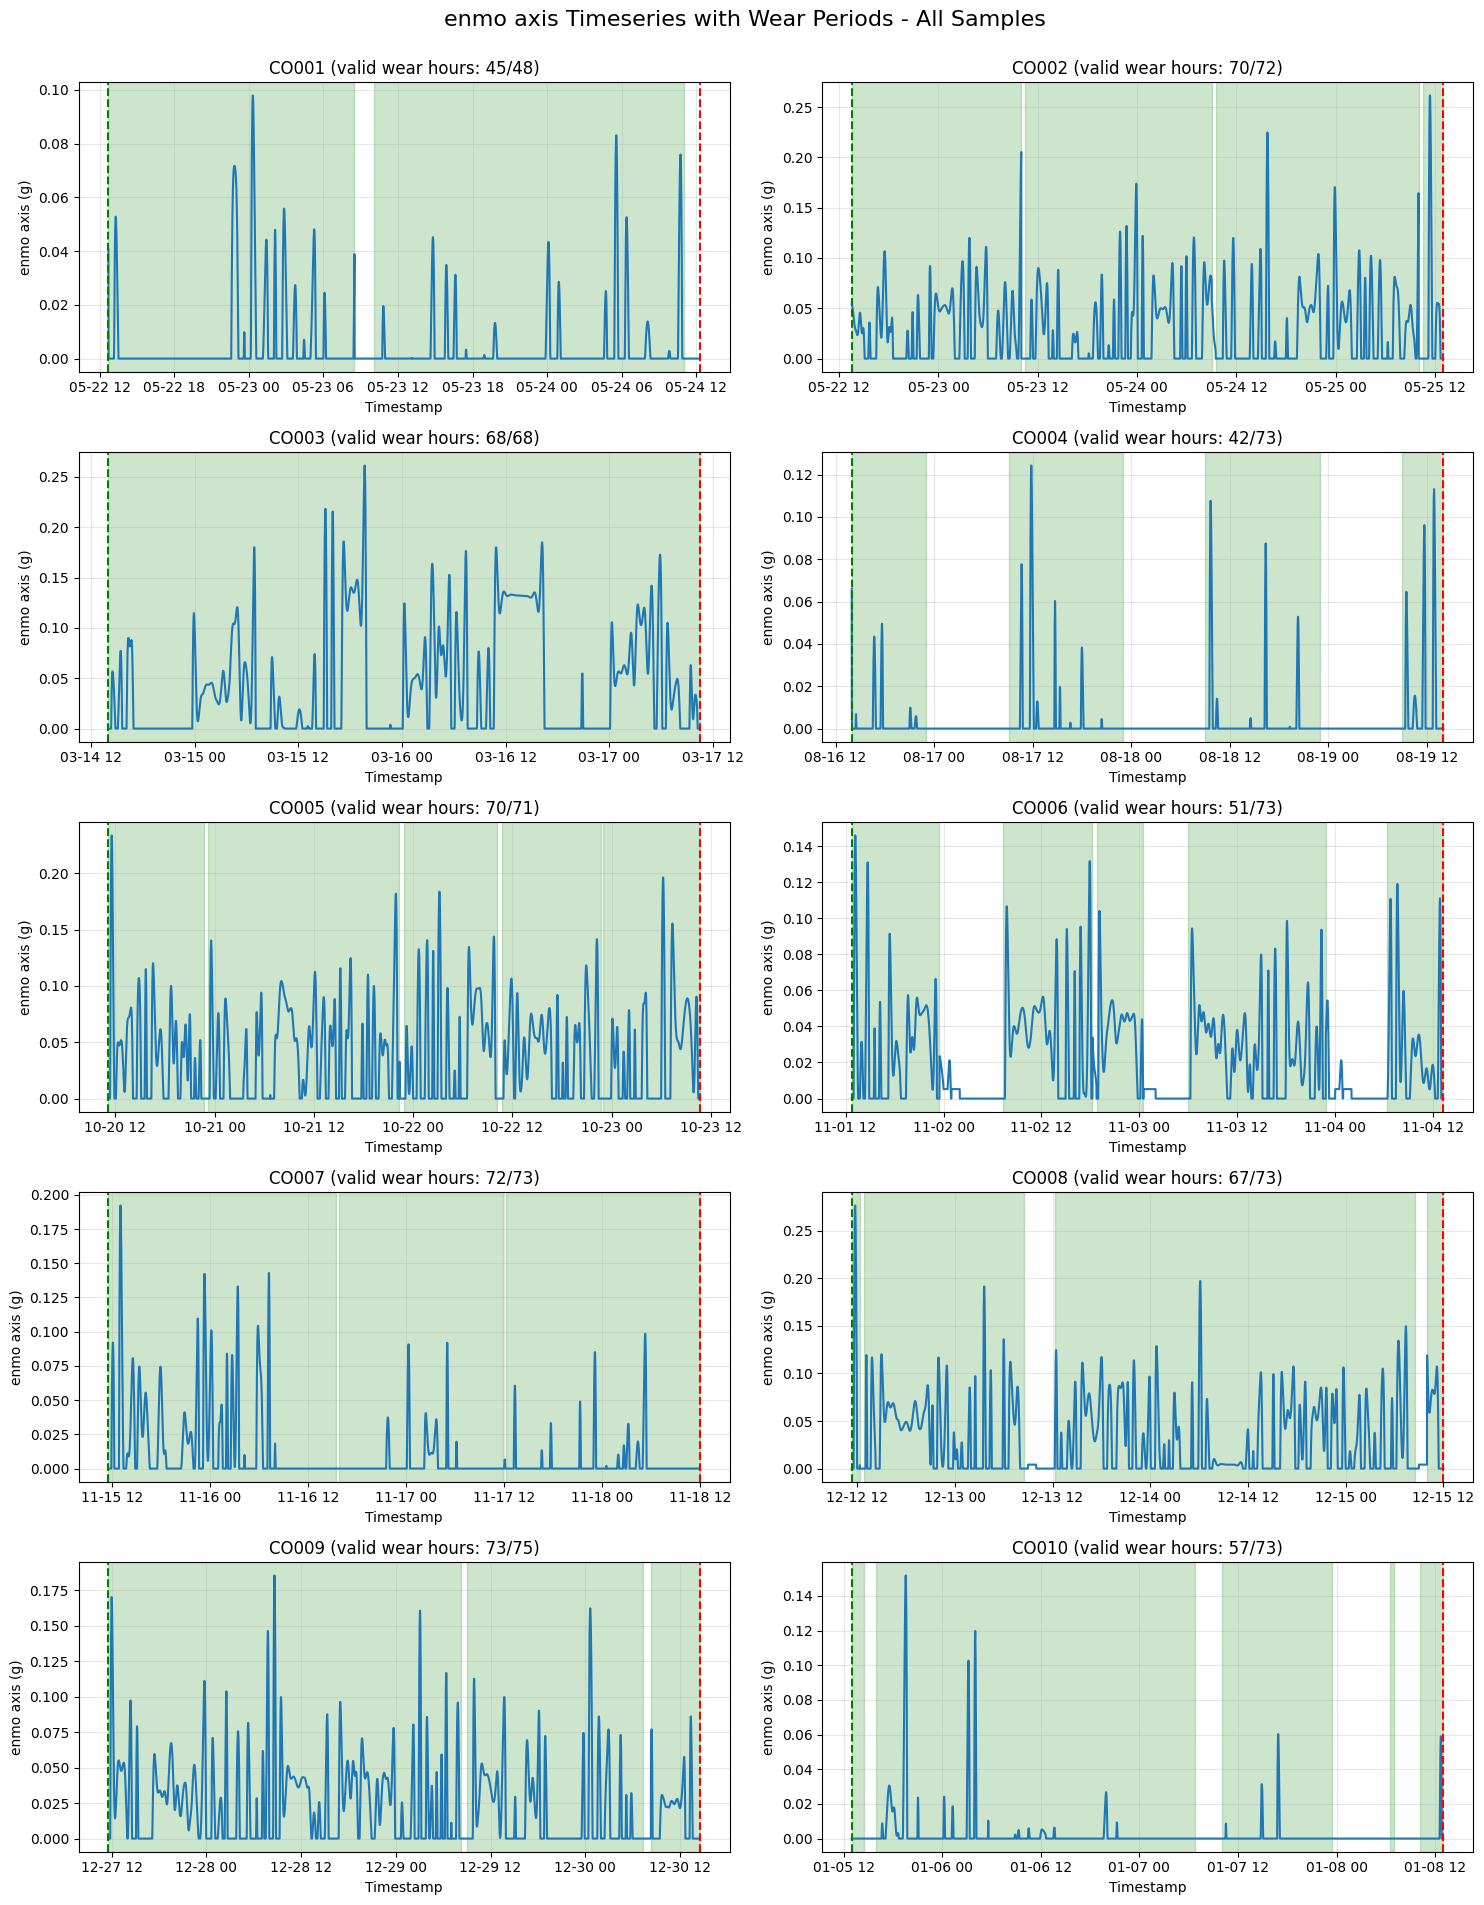

In [139]:
importlib.reload(utils)
from utils import save_modified_timeseries

modified_data_dir = "minute_level_modified"
reload = True

if reload:
    save_modified_timeseries(wear_file_name, orig_data_dir, output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00", smart=True, use_impute_acc=False)

plot_pig_wear_timeseries(wear_file_name, modified_data_dir, axis='enmo', limit=10)

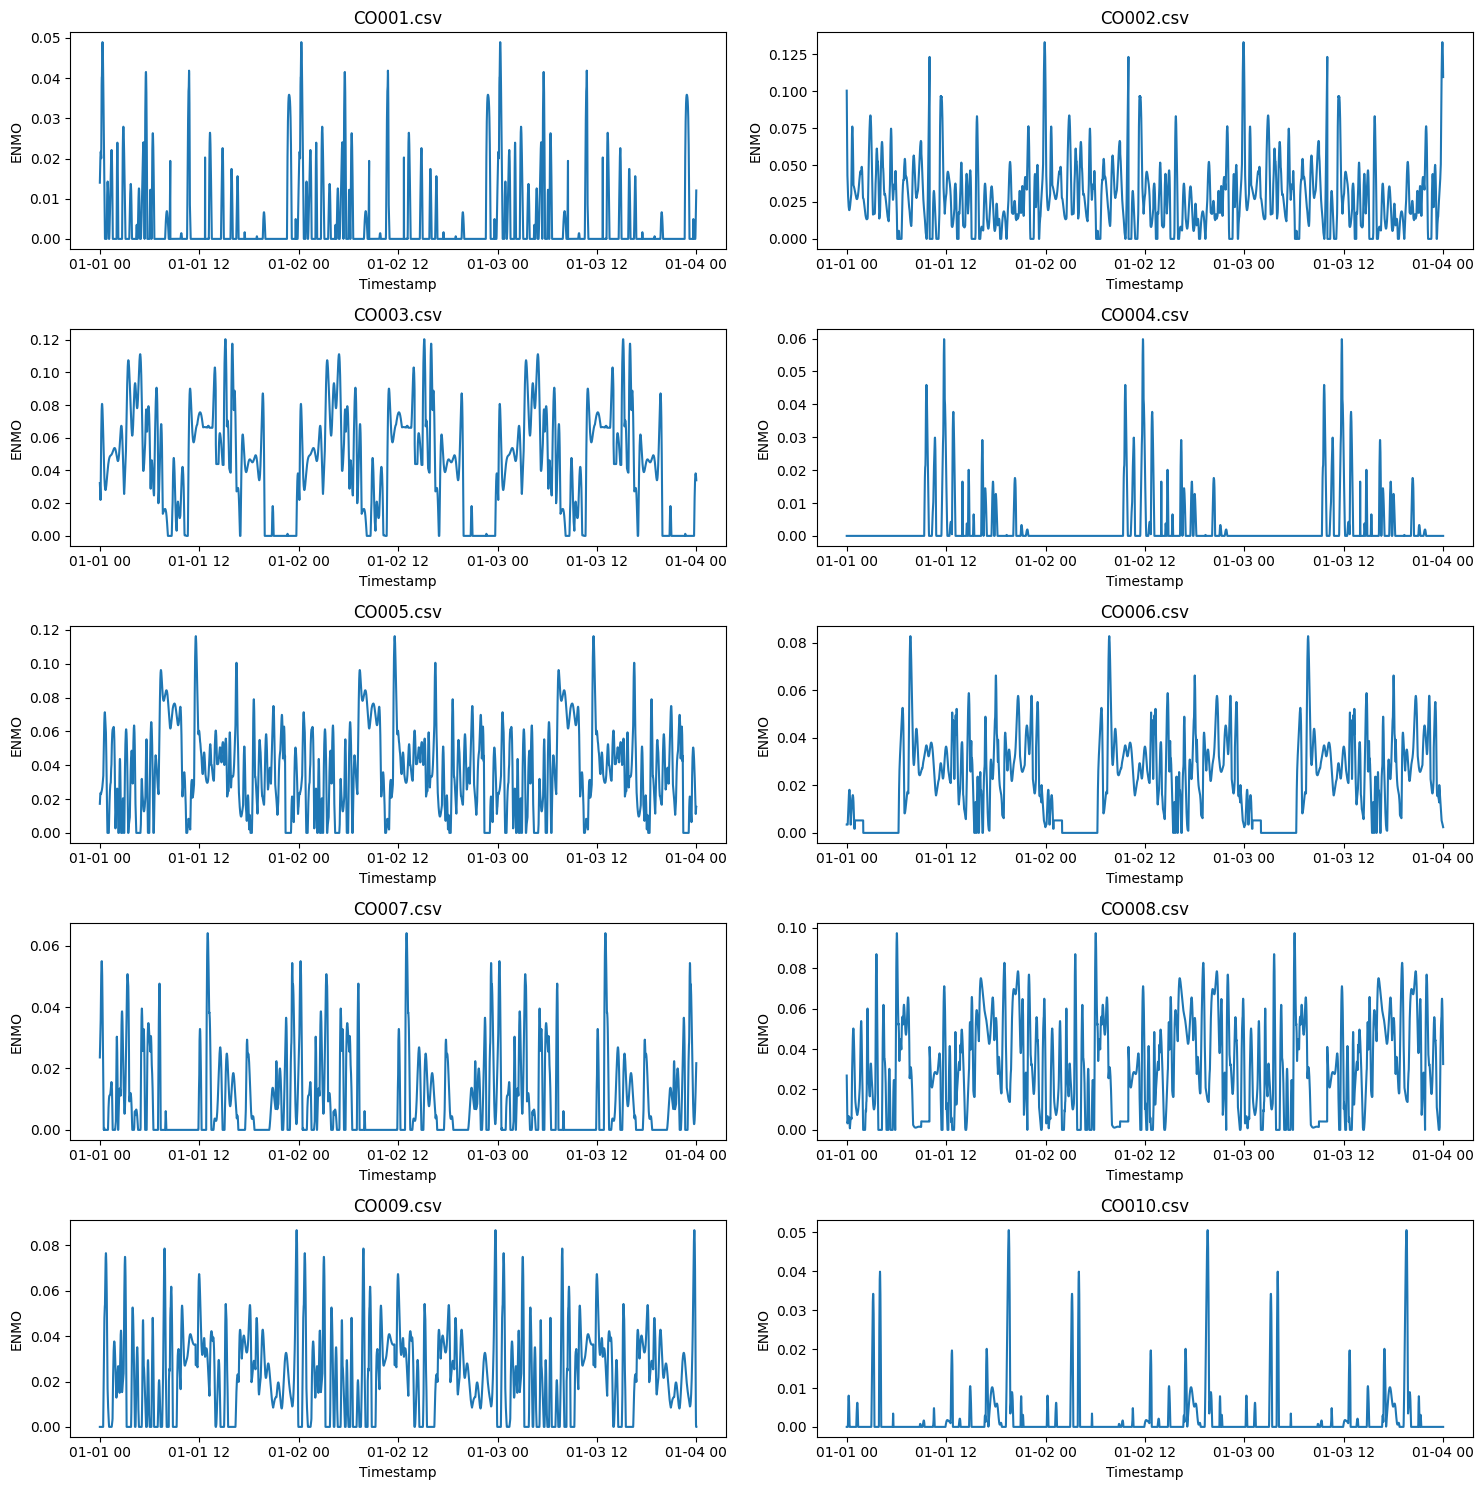

In [ ]:
# Define the directory containing the modified data
input_dir = "minute_level_modified"
output_dir = "minute_level_24h_pattern"

# Get list of all .csv files in input directory
files = sorted([f for f in os.listdir(input_dir) if f.endswith('.csv')])


# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Process each file
for file in files:
    # Read the file
    file_path = os.path.join(input_dir, file)
    df = pd.read_csv(file_path, parse_dates=['timestamp'])
    df = df.set_index('timestamp')

    # Create a column for time of day as HH:MM string (without date)
    df['time_of_day'] = df.index.strftime('%H:%M')

    # Group by time_of_day and compute mean for each column
    mean_24h = df.groupby('time_of_day').mean()

    # Replicate the 24h timeseries for 3 days
    replicated_24h = mean_24h.loc[mean_24h.index.repeat(3)].reset_index(drop=True)

    # Replicate the full 24h profile so we get three days (3 x 24h)
    n_times = mean_24h.shape[0]
    # Repeat the full 24h profile 3 times (not just each row 3 times)
    replicated_24h = pd.concat([mean_24h]*3, ignore_index=True)
    # Create a new timestamp column: for 3 days, from 1970-01-01 00:00 to 1970-01-03 23:59, at 1-minute intervals
    total_minutes = n_times * 3
    start_time = pd.Timestamp("1970-01-01 00:00")
    timestamps = [start_time + pd.Timedelta(minutes=i) for i in range(total_minutes)]
    new_df = pd.DataFrame(replicated_24h)
    new_df.insert(0, 'timestamp', timestamps)

    # Save the new DataFrame to the output directory
    new_df.to_csv(output_dir + "/" + file, index=False)

# Plot all files in output_dir in a single figure with subplots (3 columns), file name in title
limit = 10
if limit is None:
    n_rows = math.ceil(len(files) / 2)
else:
    n_rows = math.ceil(limit / 2)


fig, axes = plt.subplots(n_rows, 2, figsize=(15, 3 * n_rows), sharex=False)
axes = axes.flatten()  # Flatten in case of single row

for idx, file in enumerate(files):
    if idx >= limit:
        break
    file_path = os.path.join(output_dir, file)
    df = pd.read_csv(file_path, parse_dates=['timestamp'])
    df = df.set_index('timestamp')
    ax = axes[idx]
    ax.plot(df['enmo'])
    ax.set_title(file)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('ENMO')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()